#### Exploratory Data Analysis (EDA)

This notebook performs exploratory data analysis on the cleaned road accident dataset using PySpark and visualizes key patterns using Matplotlib. The analysis helps identify trends related to accident severity, time, weather, road conditions, vehicle types, and other factors.

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import *

import pandas as pd
import matplotlib.pyplot as plt

In [2]:
spark = (
    SparkSession.builder
    .appName("Road Safety EDA")
    .master("local[*]")
    .getOrCreate()
)

26/07/30 17:41:26 WARN Utils: Your hostname, LAPTOP-S89A4J3G resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
26/07/30 17:41:26 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/07/30 17:41:28 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/07/30 17:41:31 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
26/07/30 17:41:31 WARN Utils: Service 'SparkUI' could not bind on port 4041. Attempting port 4042.


In [3]:
df = spark.read.csv(
    "../cleaned_data/road_accident_cleaned",
    header=True,
    inferSchema=True
)

df.createOrReplaceTempView("road_accidents")

In [4]:
print(f"Number of Rows    : {df.count()}")
print(f"Number of Columns : {len(df.columns)}")

df.printSchema()

Number of Rows    : 300491
Number of Columns : 23
root
 |-- Accident_Index: string (nullable = true)
 |-- Accident Date: date (nullable = true)
 |-- Month: string (nullable = true)
 |-- Day_of_Week: string (nullable = true)
 |-- Year: integer (nullable = true)
 |-- Junction_Control: string (nullable = true)
 |-- Junction_Detail: string (nullable = true)
 |-- Accident_Severity: string (nullable = true)
 |-- Latitude: double (nullable = true)
 |-- Light_Conditions: string (nullable = true)
 |-- Local_Authority_(District): string (nullable = true)
 |-- Carriageway_Hazards: string (nullable = true)
 |-- Longitude: double (nullable = true)
 |-- Number_of_Casualties: integer (nullable = true)
 |-- Number_of_Vehicles: integer (nullable = true)
 |-- Police_Force: string (nullable = true)
 |-- Road_Surface_Conditions: string (nullable = true)
 |-- Road_Type: string (nullable = true)
 |-- Speed_limit: integer (nullable = true)
 |-- Time: timestamp (nullable = true)
 |-- Urban_or_Rural_Area: stri

Accident Severity Distribution

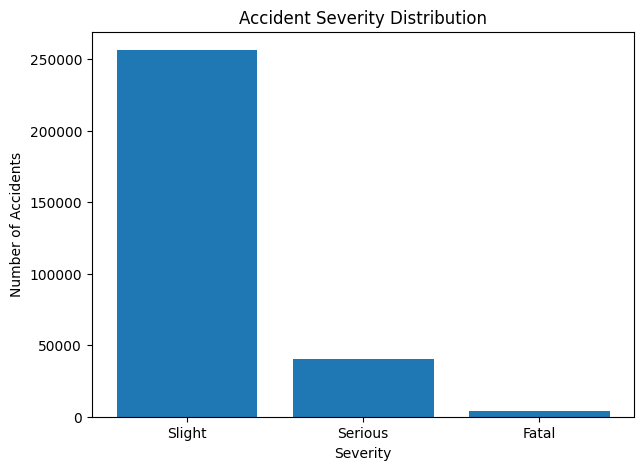

In [5]:
severity = spark.sql("""
SELECT
    Accident_Severity,
    COUNT(*) AS Total_Accidents
FROM road_accidents
GROUP BY Accident_Severity
ORDER BY Total_Accidents DESC
""")

severity_pd = severity.toPandas()

plt.figure(figsize=(7,5))

plt.bar(
    severity_pd["Accident_Severity"],
    severity_pd["Total_Accidents"]
)

plt.title("Accident Severity Distribution")
plt.xlabel("Severity")
plt.ylabel("Number of Accidents")

plt.show()

Monthly Accident Trend

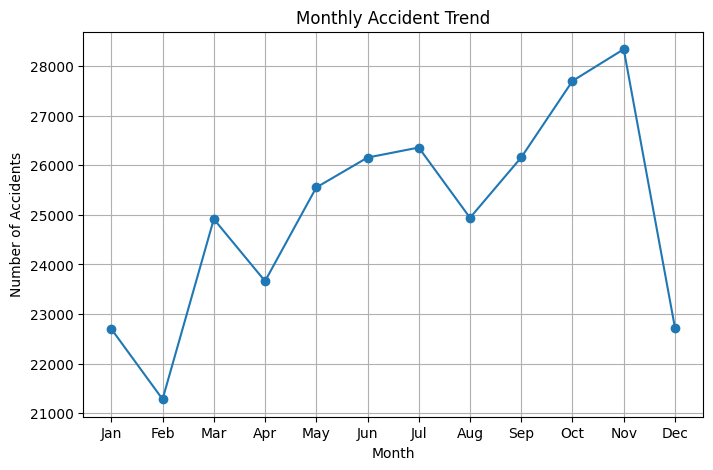

In [6]:
monthly = spark.sql("""
SELECT
    Month,
    COUNT(*) AS Total_Accidents
FROM road_accidents
GROUP BY Month
ORDER BY
CASE Month
    WHEN 'Jan' THEN 1
    WHEN 'Feb' THEN 2
    WHEN 'Mar' THEN 3
    WHEN 'Apr' THEN 4
    WHEN 'May' THEN 5
    WHEN 'Jun' THEN 6
    WHEN 'Jul' THEN 7
    WHEN 'Aug' THEN 8
    WHEN 'Sep' THEN 9
    WHEN 'Oct' THEN 10
    WHEN 'Nov' THEN 11
    WHEN 'Dec' THEN 12
END
""")

monthly_pd = monthly.toPandas()

plt.figure(figsize=(8,5))

plt.plot(
    monthly_pd["Month"],
    monthly_pd["Total_Accidents"],
    marker="o"
)

plt.title("Monthly Accident Trend")
plt.xlabel("Month")
plt.ylabel("Number of Accidents")

plt.grid(True)

plt.show()

Day-wise Accident Distribution

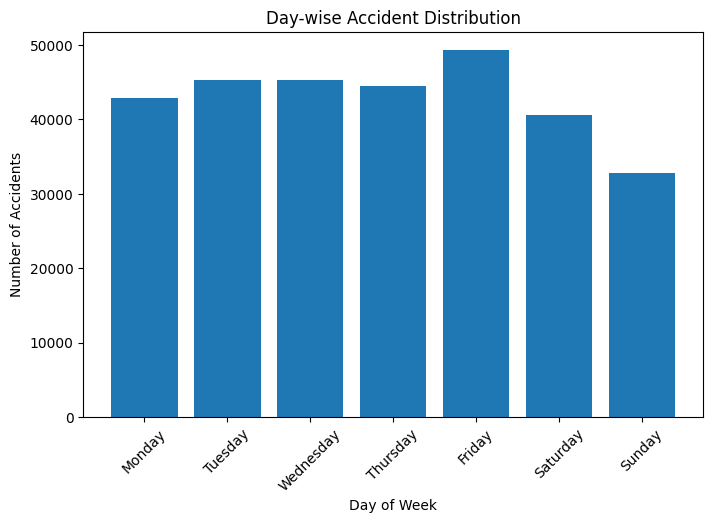

In [7]:
daywise = spark.sql("""
SELECT
    Day_of_Week,
    COUNT(*) AS Total_Accidents
FROM road_accidents
GROUP BY Day_of_Week
ORDER BY
CASE Day_of_Week
    WHEN 'Monday' THEN 1
    WHEN 'Tuesday' THEN 2
    WHEN 'Wednesday' THEN 3
    WHEN 'Thursday' THEN 4
    WHEN 'Friday' THEN 5
    WHEN 'Saturday' THEN 6
    WHEN 'Sunday' THEN 7
END
""")

daywise_pd = daywise.toPandas()

plt.figure(figsize=(8,5))

plt.bar(
    daywise_pd["Day_of_Week"],
    daywise_pd["Total_Accidents"]
)

plt.title("Day-wise Accident Distribution")
plt.xlabel("Day of Week")
plt.ylabel("Number of Accidents")

plt.xticks(rotation=45)

plt.show()

Weather Conditions Analysis

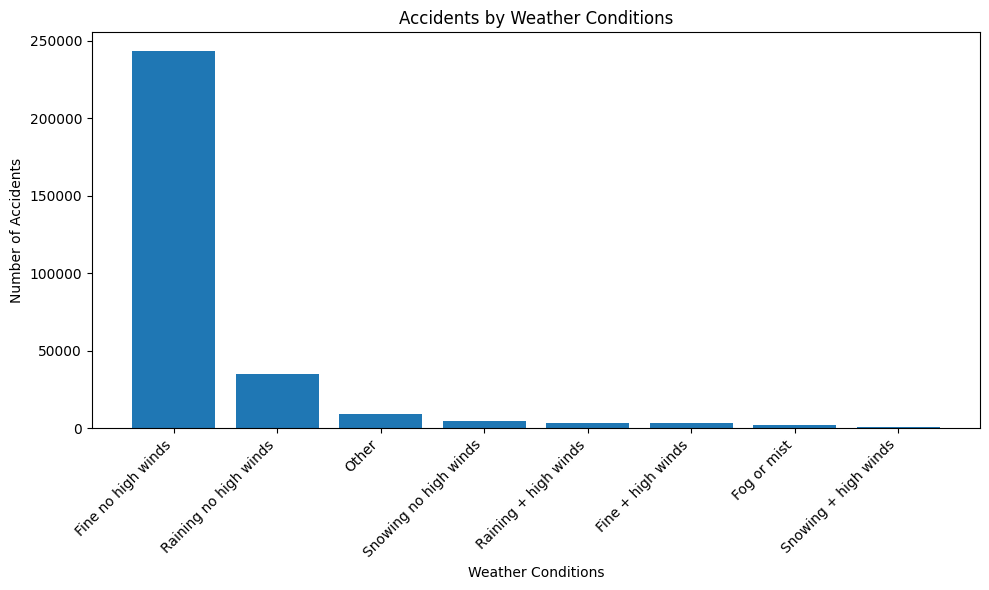

In [8]:
weather = spark.sql("""
SELECT
    Weather_Conditions,
    COUNT(*) AS Total_Accidents
FROM road_accidents
GROUP BY Weather_Conditions
ORDER BY Total_Accidents DESC
""")

weather_pd = weather.toPandas()

plt.figure(figsize=(10,6))

plt.bar(
    weather_pd["Weather_Conditions"],
    weather_pd["Total_Accidents"]
)

plt.title("Accidents by Weather Conditions")
plt.xlabel("Weather Conditions")
plt.ylabel("Number of Accidents")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.show()

Road Surface Condition Analysis

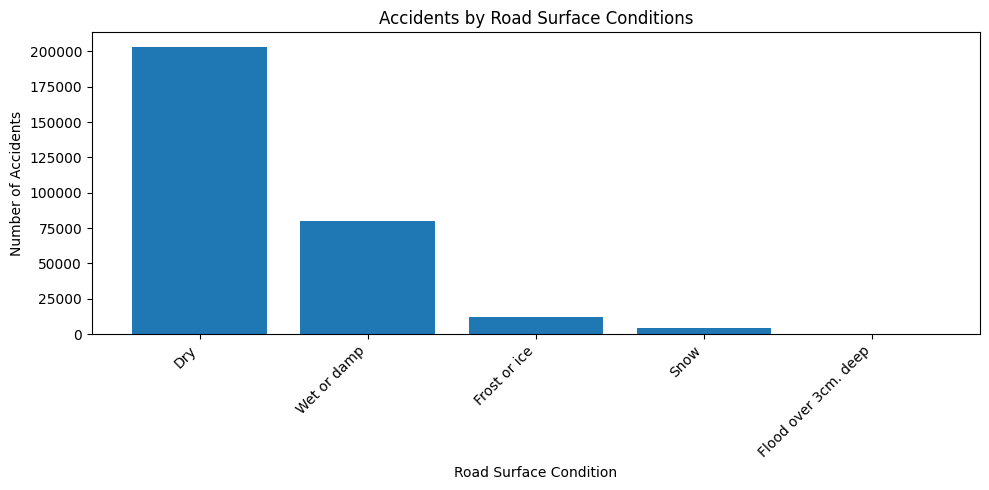

In [9]:
road_surface = spark.sql("""
SELECT
    Road_Surface_Conditions,
    COUNT(*) AS Total_Accidents
FROM road_accidents
GROUP BY Road_Surface_Conditions
ORDER BY Total_Accidents DESC
""")

road_surface_pd = road_surface.toPandas()

plt.figure(figsize=(10,5))

plt.bar(
    road_surface_pd["Road_Surface_Conditions"],
    road_surface_pd["Total_Accidents"]
)

plt.title("Accidents by Road Surface Conditions")
plt.xlabel("Road Surface Condition")
plt.ylabel("Number of Accidents")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.show()

Top 10 Vehicle Types Involved in Accidents

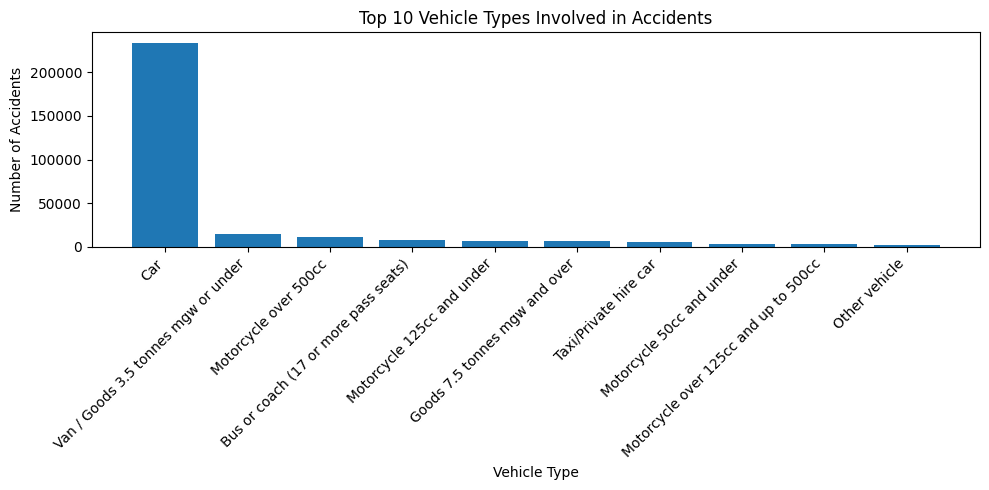

In [10]:
vehicle = spark.sql("""
SELECT
    Vehicle_Type,
    COUNT(*) AS Total_Accidents
FROM road_accidents
GROUP BY Vehicle_Type
ORDER BY Total_Accidents DESC
LIMIT 10
""")

vehicle_pd = vehicle.toPandas()

plt.figure(figsize=(10,5))

plt.bar(
    vehicle_pd["Vehicle_Type"],
    vehicle_pd["Total_Accidents"]
)

plt.title("Top 10 Vehicle Types Involved in Accidents")
plt.xlabel("Vehicle Type")
plt.ylabel("Number of Accidents")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.show()

Speed Limit Distribution

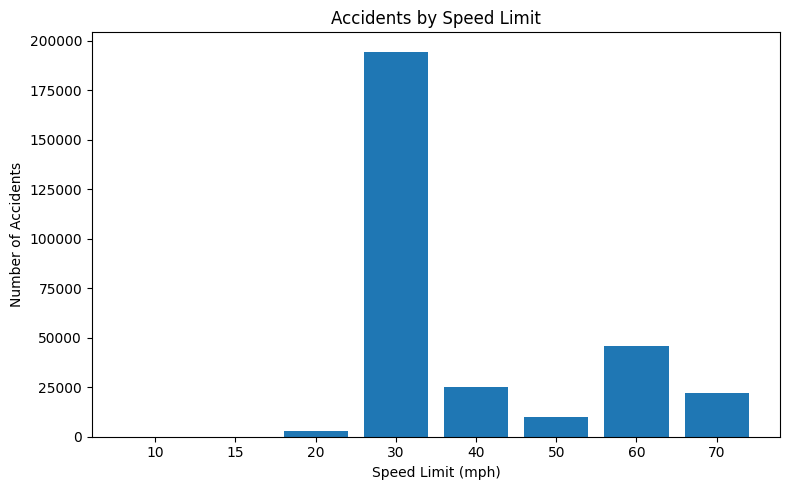

In [11]:
speed = spark.sql("""
SELECT
    Speed_limit,
    COUNT(*) AS Total_Accidents
FROM road_accidents
GROUP BY Speed_limit
ORDER BY Speed_limit
""")

speed_pd = speed.toPandas()

plt.figure(figsize=(8,5))

plt.bar(
    speed_pd["Speed_limit"].astype(str),
    speed_pd["Total_Accidents"]
)

plt.title("Accidents by Speed Limit")
plt.xlabel("Speed Limit (mph)")
plt.ylabel("Number of Accidents")

plt.tight_layout()

plt.show()

Urban vs Rural Accident Distribution

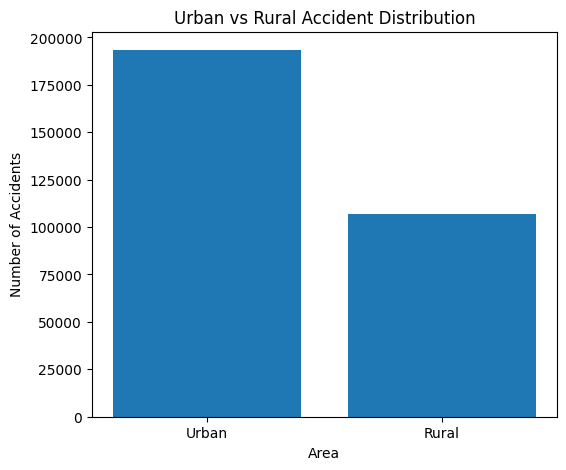

In [13]:
urban = spark.sql("""
SELECT
    Urban_or_Rural_Area,
    COUNT(*) AS Total_Accidents
FROM road_accidents
GROUP BY Urban_or_Rural_Area
ORDER BY Total_Accidents DESC
""")

urban_pd = urban.toPandas()

plt.figure(figsize=(6,5))

plt.bar(
    urban_pd["Urban_or_Rural_Area"],
    urban_pd["Total_Accidents"]
)

plt.title("Urban vs Rural Accident Distribution")
plt.xlabel("Area")
plt.ylabel("Number of Accidents")

plt.show()

Correlation Heatmap

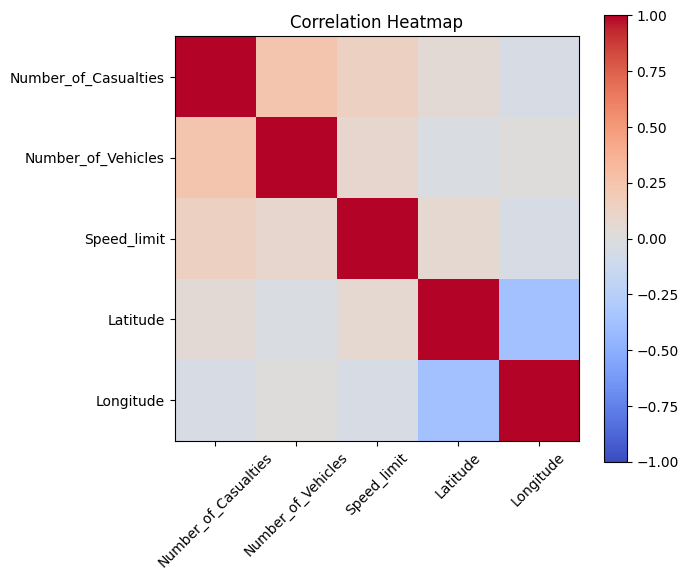

In [16]:
numeric_df = df.select(
    "Number_of_Casualties",
    "Number_of_Vehicles",
    "Speed_limit",
    "Latitude",
    "Longitude"
)

corr_pd = numeric_df.toPandas()

corr = corr_pd.corr(numeric_only=True)

plt.figure(figsize=(7,6))

plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)

plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.show()

Box Plot of Number of Casualties

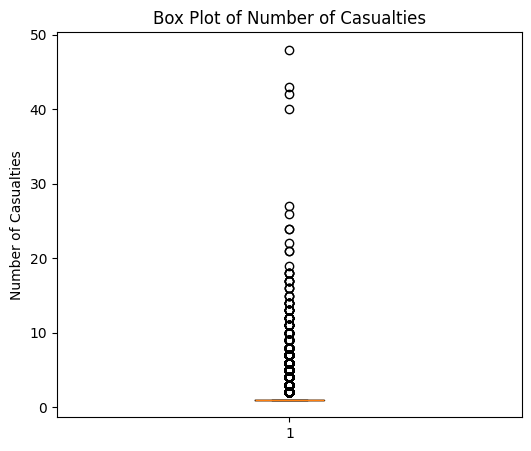

In [17]:
casualties_pd = df.select("Number_of_Casualties").toPandas()

plt.figure(figsize=(6,5))

plt.boxplot(casualties_pd["Number_of_Casualties"])

plt.title("Box Plot of Number of Casualties")
plt.ylabel("Number of Casualties")

plt.show()